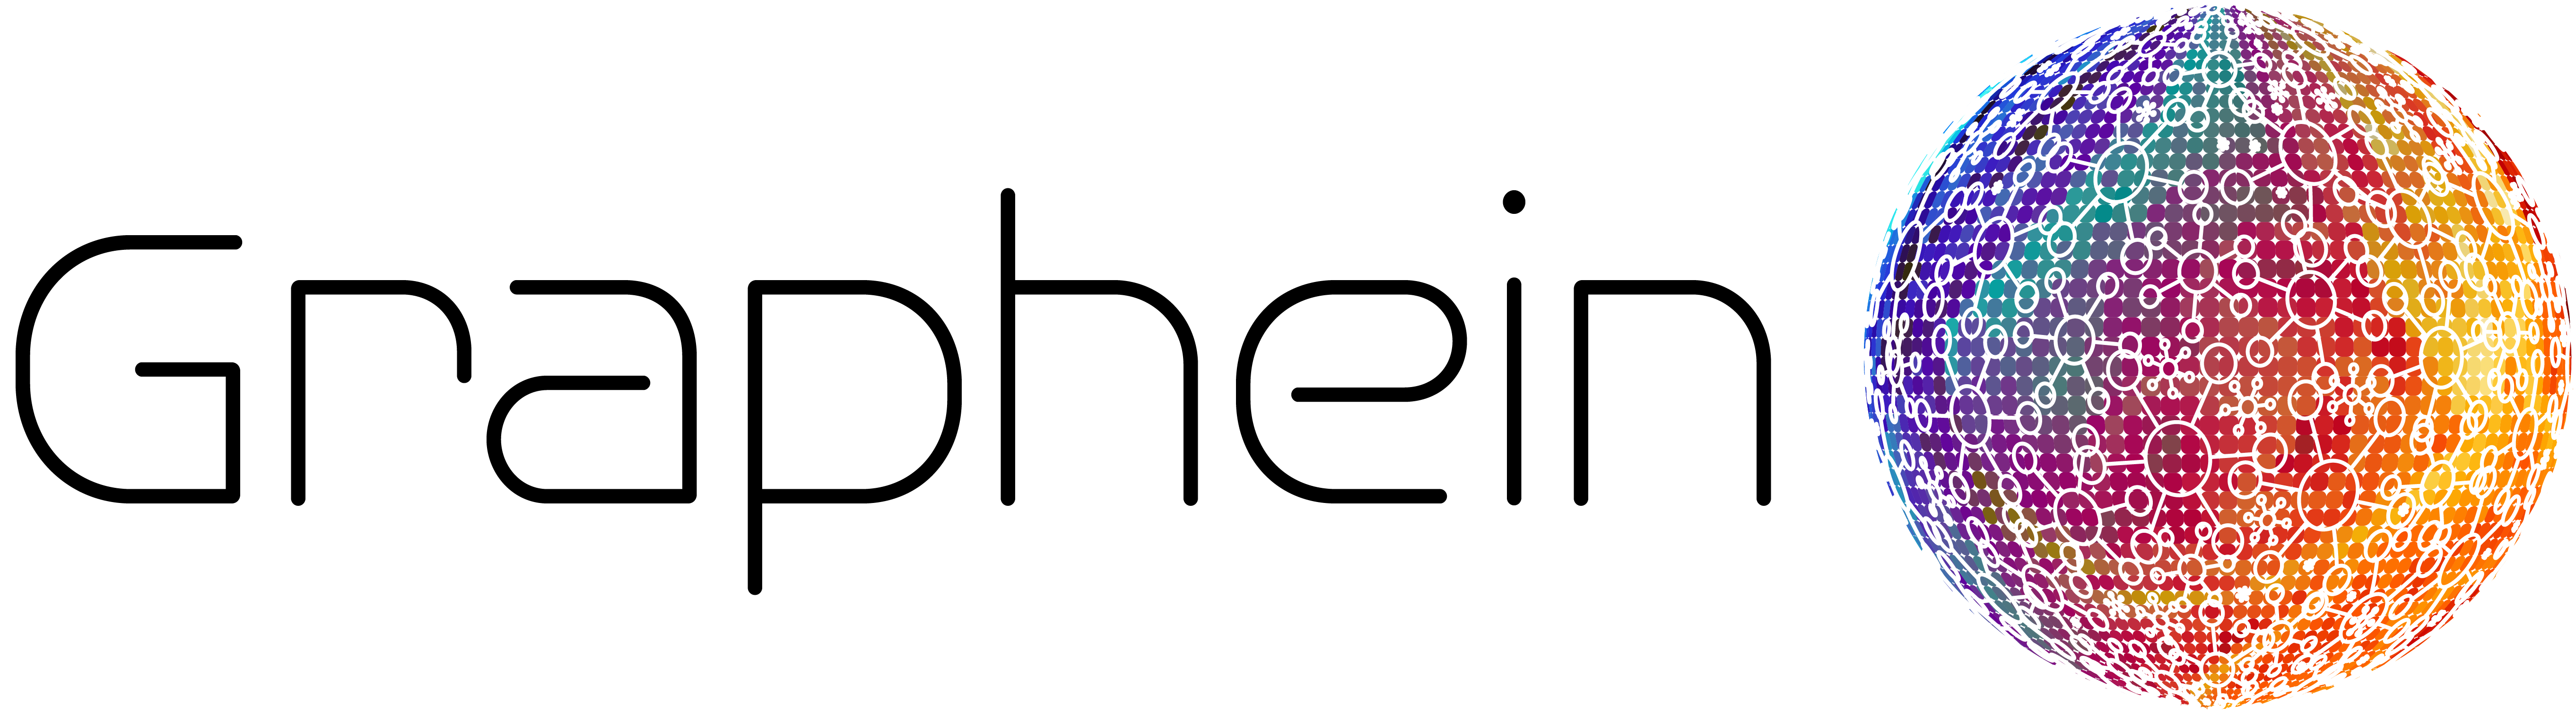

## Protein & Interactomic Graph Library

This package provides functionality for producing geometric representations of protein and RNA structures, and biological interaction networks. We provide compatibility with standard PyData formats, as well as graph objects designed for ease of use with popular deep learning libraries.



In [15]:
# Install Graphein if necessary
!pip install graphein

# Install pymol if necessary - in this tutorial PyMol is only used for the initial plot. Feel free to skip!
!apt-get install pymol

zsh:1: command not found: apt-get


In [16]:
from graphein.utils.pymol import MolViewer
pymol = MolViewer()
pymol.delete("all") # delete all objects from other sessions if necessary.
pymol.fetch("5k9x")
pymol.show_as("cartoon")
pymol.display()

MissingDependencyError: Missing dependencies: pymol

In [11]:
from graphein.protein.config import ProteinGraphConfig

config = ProteinGraphConfig()
config.dict()

/var/folders/92/ygd4xg0120nc10qf_vg3crnm0000gp/T/ipykernel_55137/3491009111.py:4: PydanticDeprecatedSince20:

The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/



{'granularity': 'CA',
 'keep_hets': [],
 'insertions': True,
 'alt_locs': 'max_occupancy',
 'pdb_dir': None,
 'verbose': False,
 'exclude_waters': True,
 'deprotonate': False,
 'protein_df_processing_functions': None,
 'edge_construction_functions': [<function graphein.protein.edges.distance.add_peptide_bonds(G: 'nx.Graph') -> 'nx.Graph'>],
 'node_metadata_functions': [<function graphein.protein.features.nodes.amino_acid.meiler_embedding(n: str, d: Dict[str, Any], return_array: bool = False) -> Union[pandas.core.series.Series, numpy.ndarray]>],
 'edge_metadata_functions': None,
 'graph_metadata_functions': None,
 'get_contacts_config': None,
 'dssp_config': None}

In [12]:
from graphein.protein.graphs import construct_graph

g = construct_graph(config=config, pdb_code="5k9x")

Output()

In [13]:
from graphein.protein.visualisation import plotly_protein_structure_graph

p = plotly_protein_structure_graph(
    g,
    colour_edges_by="kind",
    colour_nodes_by="degree",
    label_node_ids=False,
    plot_title="Peptide backbone graph. Nodes coloured by degree.",
    node_size_multiplier=1
    )
p.show()